In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("Netflix TV Shows and Movies.csv")



In [ ]:
# Fill missing values
df = df.fillna(0)

# Select correct columns
df = df[['type', 'release_year', 'runtime', 'imdb_score', 'imdb_votes', 'age_certification']]



In [ ]:
# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])
# Convert 'age_certification' to string type before encoding to handle mixed types
df['age_certification'] = df['age_certification'].astype(str)
df['age_certification'] = le.fit_transform(df['age_certification'])



In [ ]:
df

,type,release_year,runtime,imdb_score,imdb_votes,age_certification
0,0,1976,113,8.3,795222.0,5
1,0,1975,91,8.2,530877.0,3
2,0,1979,94,8.0,392419.0,5
3,0,1973,133,8.1,391942.0,5
4,1,1969,30,8.8,72895.0,6
...,...,...,...,...,...,...
5278,0,2021,108,5.8,26.0,0
5279,0,2021,100,6.9,39.0,0
5280,0,2021,88,6.5,32.0,0
5281,0,2021,116,6.2,9.0,0


In [ ]:
# Features and target
X = df[['release_year', 'runtime', 'imdb_score', 'imdb_votes', 'age_certification']]
y = df['type']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)



In [ ]:
# Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
model.score(X_test, y_test)*100

96.02649006622516

In [ ]:

# Accuracy
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred)*100)

Accuracy: 96.02649006622516


In [ ]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

In [ ]:
model1 = DecisionTreeClassifier()
model1.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
# Prediction
from sklearn.metrics import accuracy_score

In [ ]:
y_pred = model1.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred)*100)

Decision Tree Accuracy: 97.06717123935667


In [ ]:
# Scaling (IMPORTANT)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# KNN Model
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Prediction
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred)*100)

KNN Accuracy: 96.59413434247871


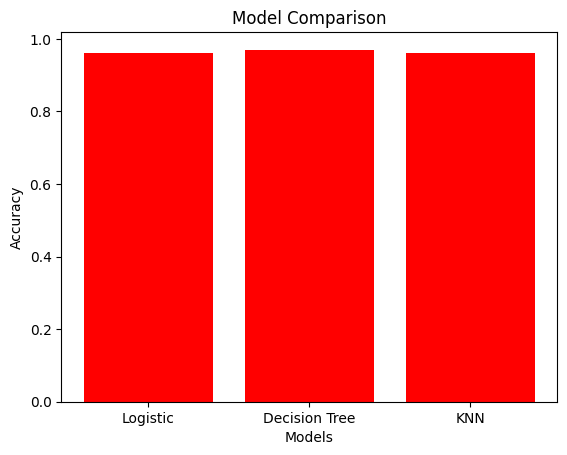

In [ ]:
import matplotlib.pyplot as plt

# Store accuracies (example values, replace with your results)
models = ['Logistic', 'Decision Tree', 'KNN']
accuracy = [0.96, 0.97, 0.96]

plt.bar(models, accuracy, color='red')
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.show()

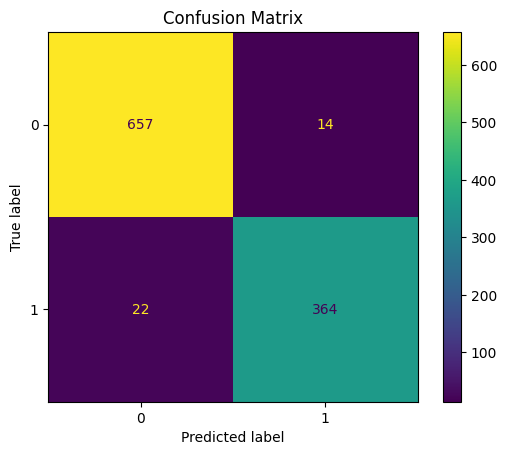

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

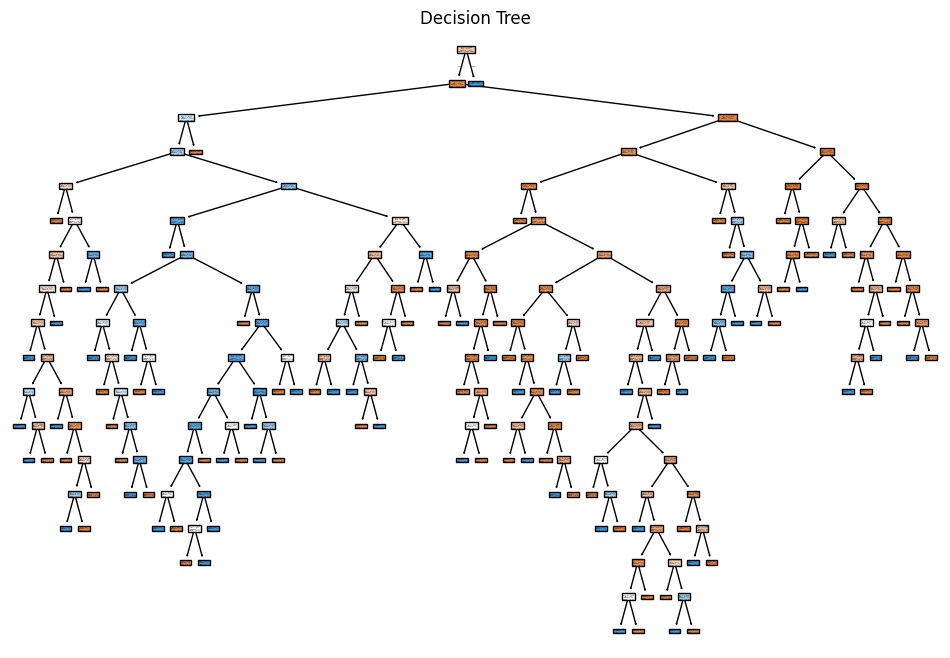

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(model1, filled=True)
plt.title("Decision Tree")
plt.show()

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


In [6]:

data= pd.DataFrame(
    {
        "height": [ 150,152,155,160,162,165,170,172,175,178,180],
        "weight": [50,52,55,60,62,65,70,72,75,78,80],
        "label" : [0,0,0,0,0,0,1,1,1,1,1]
    }
)

In [8]:
x= data.iloc[:,:-1]
y=data["label"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [12]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [13]:
model.predict([[155,35]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0])

In [14]:
h=0.05
x_min, x_max = data['height'].min()-2, x['height'].max()+2
y_min, y_max = data['weight'].min()-2, x['weight'].max()+2

In [19]:
xx,yy= np.meshgrid(np.arange(x_min,x_max,h),np.arange(y_min,y_max,h))
z=model.predict(np.c_[xx.ravel(),yy.ravel()])
z=z.reshape(xx.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


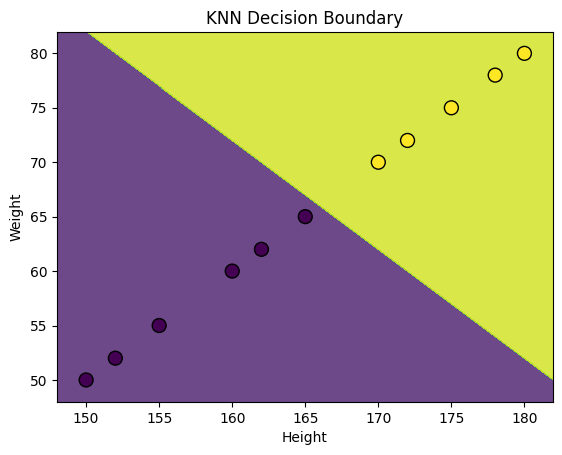

In [21]:
plt.contourf(xx, yy, z, alpha=0.8)
plt.scatter(x['height'], x['weight'], c=y, s=100, edgecolors='black')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('KNN Decision Boundary')
plt.show()